In [57]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch.nn as nn
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset

In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

In [59]:
train_df = pd.read_csv("data/asl_data/sign_mnist_train.csv")
valid_df = pd.read_csv("data/asl_data/sign_mnist_valid.csv")

In [60]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,12,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [61]:
y_train = train_df.pop('label')
y_valid = valid_df.pop('label')
y_train

0         3
1         6
2         2
3         2
4        12
         ..
27450    12
27451    22
27452    17
27453    16
27454    22
Name: label, Length: 27455, dtype: int64

In [62]:
x_train = train_df.values
x_valid = valid_df.values
x_train

array([[107, 118, 127, ..., 204, 203, 202],
       [155, 157, 156, ..., 103, 135, 149],
       [187, 188, 188, ..., 195, 194, 195],
       ...,
       [174, 174, 174, ..., 202, 200, 200],
       [177, 181, 184, ...,  64,  87,  93],
       [179, 180, 180, ..., 205, 209, 215]])

In [63]:
x_train.shape

(27455, 784)

In [64]:
y_train.shape

(27455,)

In [65]:
x_valid.shape

(7172, 784)

In [66]:
y_valid.shape

(7172,)

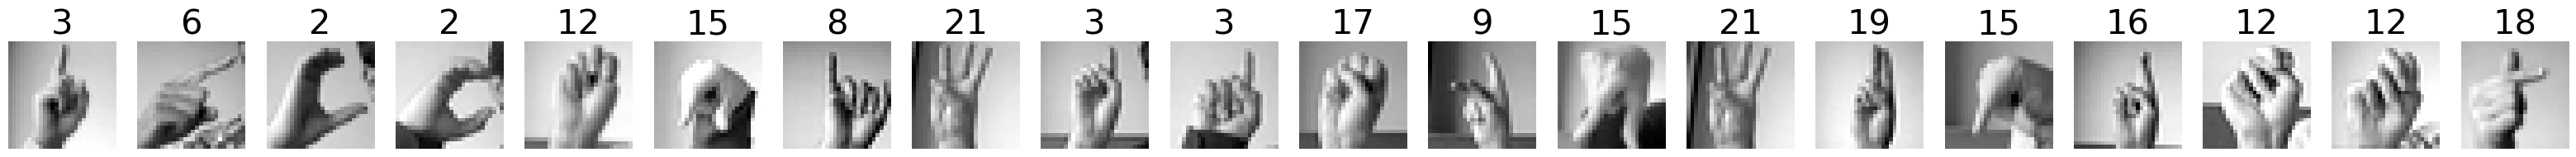

In [67]:
import matplotlib.pyplot as plt
plt.figure(figsize=(40,40))

num_images = 20
for i in range(num_images):
    row = x_train[i]
    label = y_train[i]

    image = row.reshape(28,28)
    plt.subplot(1, num_images, i+1)
    plt.title(label, fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(image, cmap='gray')

In [68]:
x_train.min()

np.int64(0)

In [69]:
x_train.max()

np.int64(255)

In [70]:
x_train = train_df.values / 255
x_valid = valid_df.values / 255

In [71]:
class MyDataset(Dataset):
    def __init__(self, x_df, y_df):
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [72]:
BATCH_SIZE = 32

train_data = MyDataset(x_train, y_train)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
train_N = len(train_loader.dataset)

In [73]:
valid_data = MyDataset(x_valid, y_valid)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE)
valid_N = len(valid_loader.dataset)

In [74]:
train_loader

In [75]:
batch = next(iter(train_loader))
batch

[tensor([[0.5882, 0.6000, 0.6039,  ..., 0.1608, 0.0980, 0.0000],
         [0.5098, 0.5216, 0.5333,  ..., 0.7176, 0.7176, 0.7176],
         [0.1216, 0.1922, 0.2039,  ..., 0.6784, 0.6784, 0.6784],
         ...,
         [0.7294, 0.7412, 0.7490,  ..., 0.9059, 0.8980, 0.8863],
         [0.8275, 0.8314, 0.8353,  ..., 0.3804, 0.5098, 0.8314],
         [0.6745, 0.6784, 0.6824,  ..., 0.1098, 0.1294, 0.1490]]),
 tensor([ 8,  8, 19, 11,  5, 17,  8,  8, 23, 10, 18, 15,  9,  7, 22, 10,  1,  9,
         17, 20,  8,  3, 10, 10,  4, 23, 18,  3,  5, 13,  7, 10])]

In [76]:
batch[0].shape

torch.Size([32, 784])

In [77]:
batch[1].shape

torch.Size([32])

In [78]:
input_size = 28 * 28
n_classes = 26

In [79]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(input_size, 512),  # Input
    nn.ReLU(),  # Activation for input
    nn.Linear(512, 512),  # Hidden
    nn.ReLU(),  # Activation for hidden
    nn.Linear(512, n_classes)  # Output
)

In [80]:
model = model.to(device)
model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=512, bias=True)
  (4): ReLU()
  (5): Linear(in_features=512, out_features=26, bias=True)
)

In [81]:
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters())

In [82]:
def train():
    loss = 0
    accuracy = 0

    model.train()
    for x, y in train_loader:
        output = model(x)
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss.item()
        accuracy += get_batch_accuracy(output, y, train_N)
    print('Train - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [83]:
def validate():
    loss = 0
    accuracy = 0

    model.eval()
    with torch.no_grad():
        for x, y in valid_loader:
            output = model(x)

            loss += loss_function(output, y).item()
            accuracy += get_batch_accuracy(output, y, valid_N)
    print('Valid - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [84]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [85]:
epochs = 20

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    train()
    validate()

Epoch: 0
Train - Loss: 1547.0124 Accuracy: 0.4125
Valid - Loss: 284.9878 Accuracy: 0.5828
Epoch: 1
Train - Loss: 699.8974 Accuracy: 0.7243
Valid - Loss: 236.1782 Accuracy: 0.6429
Epoch: 2
Train - Loss: 345.0614 Accuracy: 0.8672
Valid - Loss: 213.0122 Accuracy: 0.7288
Epoch: 3
Train - Loss: 202.4995 Accuracy: 0.9231
Valid - Loss: 212.6313 Accuracy: 0.7476
Epoch: 4
Train - Loss: 121.9592 Accuracy: 0.9545
Valid - Loss: 204.2067 Accuracy: 0.7719
Epoch: 5
Train - Loss: 82.4005 Accuracy: 0.9711
Valid - Loss: 415.4974 Accuracy: 0.6580
Epoch: 6
Train - Loss: 53.6764 Accuracy: 0.9824
Valid - Loss: 217.8531 Accuracy: 0.7867
Epoch: 7
Train - Loss: 47.4764 Accuracy: 0.9831
Valid - Loss: 206.1041 Accuracy: 0.8270
Epoch: 8
Train - Loss: 3.0028 Accuracy: 1.0000
Valid - Loss: 230.3778 Accuracy: 0.8179
Epoch: 9
Train - Loss: 84.0460 Accuracy: 0.9704
Valid - Loss: 210.3885 Accuracy: 0.8058
Epoch: 10
Train - Loss: 31.5623 Accuracy: 0.9885
Valid - Loss: 212.1547 Accuracy: 0.8194
Epoch: 11
Train - Loss: 1.